In [15]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Import các thư viện mô hình
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Import thư viện đánh giá
from sklearn.metrics import accuracy_score, classification_report

In [16]:
train_csv = pd.read_csv('../data/processed/train.csv')
test_csv = pd.read_csv('../data/processed/test.csv')
print(train_csv.shape, test_csv.shape)

(3750, 11) (662, 11)


In [17]:
# 2. TIỀN XỬ LÝ (Mã hóa dữ liệu về dạng số)
target_col = "SOURCE"

# Xử lý train
X_train = train_csv.drop(columns=[target_col])
y_train = train_csv[target_col].map({"in": 0, "out": 1}).astype(int)

# Xử lý tập Test
X_test = test_csv.drop(columns=[target_col])
y_test = test_csv[target_col].map({'in': 0, 'out': 1}).astype(int)

# One-Hot Encoding cho cột SEX (biến đổi F/M thành 0/1)
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Đảm bảo thứ tự cột giống nhau
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")
print("-" * 30)

Kích thước tập Train: (3750, 10)
Kích thước tập Test: (662, 10)
------------------------------


In [18]:
# 3. KHỞI TẠO CÁC MÔ HÌNH
models = {
    # --- Mô hình cơ bản (Baseline) ---
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    
    # --- Mô hình cây đơn lẻ & Bagging ---
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5),
    
    # --- Mô hình Boosting (Họ hàng của XGBoost) ---
    "XGBoost (Lib)": xgb.XGBClassifier(
        n_estimators=100, 
        learning_rate=0.1, 
        max_depth=5, 
        random_state=42, 
        eval_metric='logloss'
    ),
    
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=100, 
        learning_rate=0.1, 
        max_depth=5, 
        random_state=42, 
        verbose=-1  # Tắt cảnh báo
    ),
    
    "CatBoost": CatBoostClassifier(
        iterations=100, 
        learning_rate=0.1, 
        depth=5, 
        random_seed=42, 
        verbose=0   # Tắt log in ra màn hình cho gọn
    )
}

In [20]:
# 4. HUẤN LUYỆN VÀ ĐÁNH GIÁ
results = []

for name, model in models.items():
    print(f"Dang huan luyen {name}...")
    
    # Đo thời gian huấn luyện
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Dự đoán
    y_pred = model.predict(X_test)
    
    # Tính độ chính xác
    acc = accuracy_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Time (s)": train_time
    })
    
    print(f"  -> Accuracy: {acc:.4f}")
    print(f"  -> Time: {train_time:.4f}s")
    print("-" * 30)

Dang huan luyen Logistic Regression...
  -> Accuracy: 0.7326
  -> Time: 0.2628s
------------------------------
Dang huan luyen Decision Tree...
  -> Accuracy: 0.7296
  -> Time: 0.0353s
------------------------------
Dang huan luyen Random Forest...
  -> Accuracy: 0.7462
  -> Time: 0.4855s
------------------------------
Dang huan luyen XGBoost (Lib)...
  -> Accuracy: 0.7749
  -> Time: 0.2523s
------------------------------
Dang huan luyen LightGBM...
  -> Accuracy: 0.7795
  -> Time: 0.2208s
------------------------------
Dang huan luyen CatBoost...
  -> Accuracy: 0.7568
  -> Time: 0.6233s
------------------------------


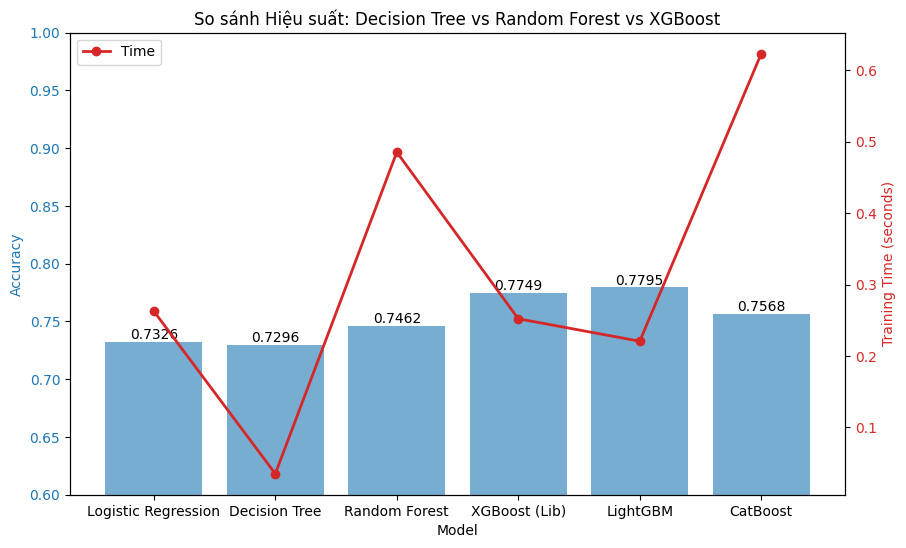


BẢNG TỔNG HỢP KẾT QUẢ:
                 Model  Accuracy  Time (s)
0  Logistic Regression  0.732628  0.262803
1        Decision Tree  0.729607  0.035283
2        Random Forest  0.746224  0.485518
3        XGBoost (Lib)  0.774924  0.252263
4             LightGBM  0.779456  0.220791
5             CatBoost  0.756798  0.623323


In [22]:
# 5. TRỰC QUAN HÓA SO SÁNH
df_results = pd.DataFrame(results)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Vẽ biểu đồ cột cho Accuracy
color = 'tab:blue'
ax1.set_xlabel('Model')
ax1.set_ylabel('Accuracy', color=color)
bars = ax1.bar(df_results['Model'], df_results['Accuracy'], color=color, alpha=0.6, label='Accuracy')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0.6, 1.0) # Giới hạn trục Y để nhìn rõ sự khác biệt

# Hiển thị giá trị lên cột
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), ha='center', va='bottom')

# Vẽ biểu đồ đường cho Thời gian (trục phụ)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Training Time (seconds)', color=color)
ax2.plot(df_results['Model'], df_results['Time (s)'], color=color, marker='o', linestyle='-', linewidth=2, label='Time')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('So sánh Hiệu suất: Decision Tree vs Random Forest vs XGBoost')
plt.legend()
plt.show()

# Hiển thị bảng kết quả chi tiết
print("\nBẢNG TỔNG HỢP KẾT QUẢ:")
print(df_results)